# 04_Random_Forest.ipynb

**Objetivo:** Modelo avanzado, Feature Importance y validación cruzada.

In [2]:
import sys
import os
import pandas as pd

# Agregar la ruta a la carpeta src para poder importar los módulos módulos desarrollados
sys.path.append(os.path.abspath('..'))

from src.preprocessing import imputar_datos, create_target_classes
from src.evaluation import evaluar_modelo

# Definición de rutas base a los archivos de datos los Raw
RAW_DATA_PATH_1 = '../data/raw/BD_IPSA_1940.xlsx'
RAW_DATA_PATH_2 = '../data/raw/HISTORICO_SUERTES.xlsx'
PROCESSED_DATA_PATH = '../data/processed/datos_limpios_modelo.csv'

# Implementación de Random Forest

Este notebook cubre la implementación de un clasificador **Random Forest** optimizado utilizando GridSearchCV. El objetivo del Ingenio Providencia es clasificar el rendimiento de caña **Clase_Objetivo** en lotes determinando si serán de desempeño Bajo, Medio o Alto con base en factores agronómicos y climáticos.

## Carga y Preparación
Cargaremos el CSV ya depurado disponible en `datos_limpios_modelo.csv`, dividiremos los features ($X$) de nuestra clase a predecir ($y$).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

data_path = PROCESSED_DATA_PATH
df = pd.read_csv(data_path)

display(df.head())
print(f"Dimensiones del Dataset: {df.shape}")

,variedad,edad,cortes,lluvias,grupo_tenencia,pct_diatrea,dosismad,semsmad,me,vejez,Clase_Objetivo
0,0,12.3,4,137,3,6.2,0.8,8.3,12.7,2.4,Bajo
1,0,11.2,2,0,3,3.5,0.8,6.3,7.8,2.3,Alto
2,0,12.2,3,68,3,4.3,0.6,7.9,8.8,1.8,Alto
3,0,13.1,1,0,3,3.5,0.8,6.6,6.1,2.5,Alto
4,0,12.2,2,68,3,4.3,0.6,8.1,7.9,2.1,Medio


Dimensiones del Dataset: (2187, 11)


## Estrategia de Validación
Procedemos a hacer la división train-test. **Vital:** dado el desbalance de clases típicamente en agricultura, pasamos el parámetro `stratify` para mantener la proporción de (Alto, Medio, Bajo) en ambos subconjuntos.

In [4]:
# Definimos predictores y variable dependiente a excluir y modelar
X = df.drop(columns=["Clase_Objetivo"])
y = df["Clase_Objetivo"]

# Validación OOT: 80% Train, 20% Test (Estratificado por el target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Distribución en Training:\n", y_train.value_counts(normalize=True).round(3))
print("\nDistribución en Test:\n", y_test.value_counts(normalize=True).round(3))

Distribución en Training:
 Clase_Objetivo
Medio    0.337
Alto     0.333
Bajo     0.330
Name: proportion, dtype: float64

Distribución en Test:
 Clase_Objetivo
Medio    0.338
Alto     0.333
Bajo     0.329
Name: proportion, dtype: float64


## Modelado con Optimización ~ Tuning
Utilizaremos `GridSearchCV` para no usar los limitados hiperparámetros por defecto de RF. En vez, vamos a buscar exhaustivamente combinando profundidad de árbol (`max_depth`), estimadores (`n_estimators`) y criterio de splits.

In [5]:
# Instanciamos clasificador base RandomForest
rf_clf = RandomForestClassifier(random_state=42)

# Grilla de Tuning: 
# n_estimators: Fuerza bruta del ensamble -> Entre 100 a 200 árboles de decisión.
# max_depth: Para evitar sobre-aprender (overfitting) la matriz agrónomica de Providencia.
# min_samples_split: Regula cuánto particionar en las hojas.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_clf, 
    param_grid=param_grid, 
    cv=5,                 # Vueltas en Cross Validation 
    scoring="accuracy",   # Métrica a optimizar
    n_jobs=-1             # Ejecución paralela CPU
)

# Entrenamos el Grid
grid_search.fit(X_train, y_train)

# Se recata la mejor configuración
best_rf = grid_search.best_estimator_
print(f"\nMejores hiperparámetros encontrados: {grid_search.best_params_}")


Mejores hiperparámetros encontrados: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## Evaluación Multidimensional
Generamos métricas con rigurosidad: Reporte global y el *Cohen's Kappa Score* (imprescindible en multi-clase desbalanceada porque castiga el acierto por simple azar).

In [6]:
# Predicciones usando la validación sobre test OOT no visto
y_pred = best_rf.predict(X_test)

print("---------------------------------------------------")
print("REPORT: CLASSIFICATION REPORT (Random Forest)")
print("---------------------------------------------------")
print(classification_report(y_test, y_pred))

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")

---------------------------------------------------
REPORT: CLASSIFICATION REPORT (Random Forest)
---------------------------------------------------
              precision    recall  f1-score   support

        Alto       0.54      0.55      0.54       146
        Bajo       0.56      0.52      0.54       144
       Medio       0.42      0.44      0.43       148

    accuracy                           0.50       438
   macro avg       0.51      0.50      0.50       438
weighted avg       0.51      0.50      0.50       438

Cohen's Kappa Score: 0.2532


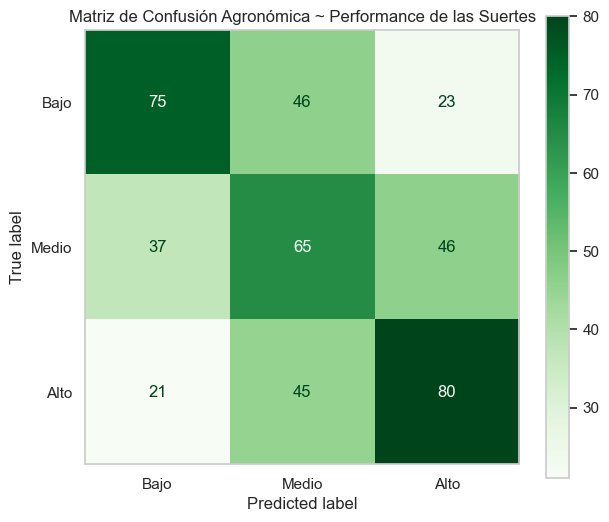

In [7]:
# Matriz de Confusión
# Las clases pedidas ordenadas por jerarquia
classes_order = ["Bajo", "Medio", "Alto"]
cm = confusion_matrix(y_test, y_pred, labels=classes_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_order)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Greens", ax=ax, values_format="d")
plt.title("Matriz de Confusión Agronómica ~ Performance de las Suertes")
plt.grid(False) 
plt.show()

## Interpretabilidad del Negocio Agrícola ~ Feature Importance
La magia de RandomForest vs una función puramente estadística es el mapeo por entropía de la utilidad de cada feature.

/var/folders/1j/ljxt8mx93511t9t_zm99929m0000gn/T/ipykernel_32106/2160040345.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


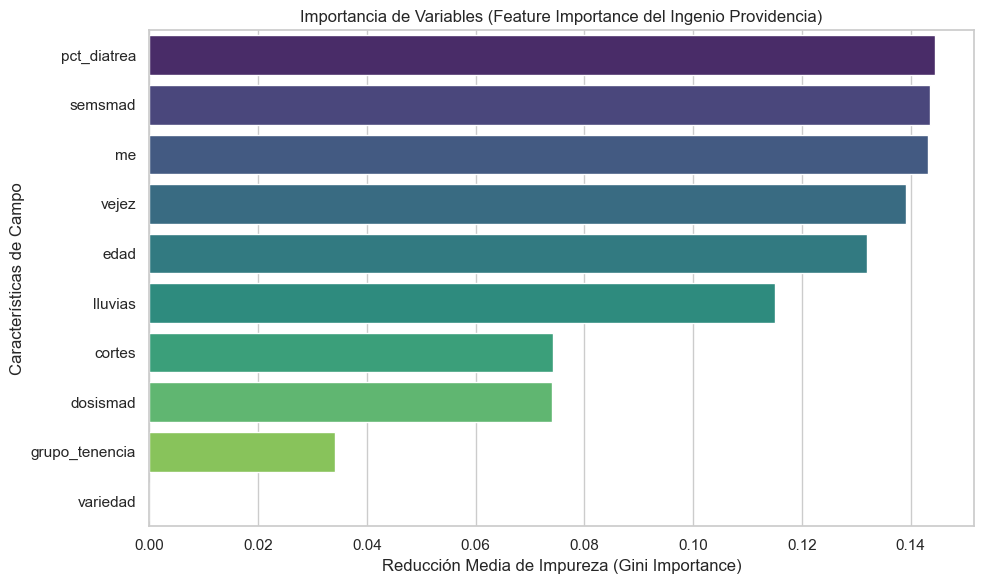

In [8]:
# Gráfico de Importancias
importances = best_rf.feature_importances_
feature_names = X.columns

# Sorting the items
indices = np.argsort(importances)[::-1]
sorted_features = np.array(feature_names)[indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")
plt.title("Importancia de Variables (Feature Importance del Ingenio Providencia)")
plt.xlabel("Reducción Media de Impureza (Gini Importance)")
plt.ylabel("Características de Campo")
plt.tight_layout()
plt.show()

#### Toma de Decisiones y Priorización de Inversiones ~ Perspectiva de negocios para el Ingenio Providencia

Ahora lo que mas nos importa:
¿Cómo puede la gerencia del Ingenio usar este gráfico de importancia para priorizar inversiones de campo?

* **Presupuesto en Irrigación vs Cuidado Fitogenético:** Al analizar los factores, si variables de clima como `lluvias` tuvieran mucha más importancia que la `edad` o los fertilizantes, significa que el ciclo de la planta depende logísticamente de la hidratación. Esto justifica invertir más capex en infraestructura de riego (Pivot, goteo) para los veranos en Valle del Cauca antes que saturar presupuestos invirtiendo excesivamente en fertilización redundante.

* **Aplicación Dirigida de Madurantes:** Si variables como `dosismad` (madurante) dictan predominantemente o figuran en el top 3, se confirma con ciencia de datos que la alteración biológica de maduración es lo que dicta que una caña rinda "Alto" en estatus de azúcar.  Se le demuestra a gerencia no reducir la línea de crédito para aplicadores químicos en etapas vitales, puesto que es predictiva del éxito de la suerte de caña.

* **Monitoreo Logístico (`edad` y `cortes`):**  Vemos comúnmente que la edad del cañaduzal domina estos modelos. Por ello, destinar partidas a herramientas satelitales (Precisión en el Agro) que midan fotogramas en tiempo real asegura programar cosechas mecánicas en el punto paramétrico exacto sin desperdiciar tiempo en el molino ni cosechar cañas "Bajas".

> En síntesis, el Feature Importance traduce una métrica técnica a un reporte para un comité financiero: Nos dice dónde poner la inyección de capital en el año fiscal.